# 08 — VQC Experiments
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Evaluate Variational Quantum Classifiers (VQC) for physiological stress classification
under LOSO cross-validation on WESAD and DREAMER.

## How VQC Works
Unlike QSVM which uses a fixed quantum kernel, VQC uses a trainable parameterized
quantum circuit (PQC) to learn the classification boundary directly:
1. Data is encoded via a ZZFeatureMap
2. A variational ansatz with trainable parameters is applied
3. Parameters are optimized using SPSA to minimize classification loss
4. Measurement outcomes determine the class prediction

## Why SPSA?
SPSA (Simultaneous Perturbation Stochastic Approximation) requires only 2 circuit
evaluations per iteration regardless of parameter count, making it computationally
practical for NISQ-era simulation. It is also more appropriate than COBYLA for
noisy quantum environments (Kandala et al., 2017).

## Experimental Grid (8 configs per task)
| Factor | Values |
|--------|--------|
| Ansatz | RealAmplitudes, EfficientSU2 |
| Entanglement | linear, circular |
| Repetitions | 1 (fixed) |
| PCA components | 3, 4 (WESAD) / 4, 6 (DREAMER) |
| Optimizer | SPSA(maxiter=100) |

## Data Conditions
- Stratified subsample: 50 windows per class per fold (train only)
- RobustScaler pre-PCA (best from QSVM experiments)
- MinMaxScaler(-pi, pi) post-PCA fixed
- Test set: all windows for held-out subject

---


## 0. Configuration

In [13]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from itertools import product

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

from qiskit.circuit.library import RealAmplitudes, EfficientSU2, ZZFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler
import logging
logging.getLogger('qiskit_machine_learning').setLevel(logging.ERROR)
logging.getLogger('qiskit_algorithms').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '08_vqc')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE         = 42
N_SAMPLES_PER_CLASS  = 30

algorithm_globals.random_seed = RANDOM_STATE

# ── VQC experiment grid (8 configs per task) ──────────────────────────────────
ANSATZ_NAMES           = ['RealAmplitudes', 'EfficientSU2']
ENTANGLEMENTS          = ['linear', 'circular']
REPS_LIST              = [1]
PCA_COMPONENTS_WESAD   = [3,4]
PCA_COMPONENTS_DREAMER = [4,6]
MAX_ITER               = 30   # SPSA iterations

# Pre-PCA  : RobustScaler (fixed — best from QSVM experiments)
# Post-PCA : MinMaxScaler(-pi, pi) (fixed — quantum angle encoding)

n_configs_wesad   = len(ANSATZ_NAMES) * len(ENTANGLEMENTS) * len(REPS_LIST) * len(PCA_COMPONENTS_WESAD)
n_configs_dreamer = len(ANSATZ_NAMES) * len(ENTANGLEMENTS) * len(REPS_LIST) * len(PCA_COMPONENTS_DREAMER)
n_configs_total   = n_configs_wesad * 2 + n_configs_dreamer

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Ansatz             : {ANSATZ_NAMES}')
print(f'  Entanglements      : {ENTANGLEMENTS}')
print(f'  Reps               : {REPS_LIST}')
print(f'  PCA WESAD          : {PCA_COMPONENTS_WESAD}')
print(f'  PCA DREAMER        : {PCA_COMPONENTS_DREAMER}')
print(f'  Optimizer          : SPSA(maxiter={MAX_ITER})')
print(f'  Subsample          : {N_SAMPLES_PER_CLASS} per class per fold')
print(f'  WESAD configs/task : {n_configs_wesad}')
print(f'  DREAMER configs    : {n_configs_dreamer}')
print(f'  Total configs      : {n_configs_total}')


Configuration ready.
  Ansatz             : ['RealAmplitudes', 'EfficientSU2']
  Entanglements      : ['linear', 'circular']
  Reps               : [1]
  PCA WESAD          : [3, 4]
  PCA DREAMER        : [4, 6]
  Optimizer          : SPSA(maxiter=30)
  Subsample          : 30 per class per fold
  WESAD configs/task : 8
  DREAMER configs    : 8
  Total configs      : 24


## 1. Load Datasets

In [14]:
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

print('=== Datasets Loaded ===')
print(f'WESAD binary   : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class  : {df_wesad_3cl.shape}')
print(f'DREAMER binary : {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')


=== Datasets Loaded ===
WESAD binary   : (883, 30)  features=26
WESAD 3-class  : (1049, 30)
DREAMER binary : (414, 146)  EEG features=134


## 2. Import & Smoke Test

In [15]:
try:
    from qiskit.circuit.library import RealAmplitudes, EfficientSU2, ZZFeatureMap
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_algorithms.optimizers import SPSA
    from qiskit.primitives import StatevectorSampler
    print('All VQC imports OK.')
except ImportError as e:
    print(f'Import error: {e}')

# Smoke test with SPSA
try:
    fm      = ZZFeatureMap(feature_dimension=3, reps=1)
    ansatz  = RealAmplitudes(num_qubits=3, reps=1, entanglement='linear')
    sampler = StatevectorSampler()
    opt     = SPSA(maxiter=10)
    vqc     = VQC(feature_map=fm, ansatz=ansatz,
                  optimizer=opt, sampler=sampler)
    X_smoke = np.random.rand(10, 3)
    y_smoke = np.array([0,1,0,1,0,1,0,1,0,1])
    t0 = time.time()
    vqc.fit(X_smoke, y_smoke)
    elapsed = time.time() - t0
    preds = vqc.predict(X_smoke[:3])
    print(f'VQC smoke test passed in {elapsed:.1f}s. Predictions: {preds}')
    print(f'Estimated time per fold (100 iters, 100 samples): '
          f'{elapsed/10*100:.0f}s')
except Exception as e:
    print(f'VQC smoke test failed: {e}')


All VQC imports OK.
VQC smoke test passed in 2.0s. Predictions: [1 1 1]
Estimated time per fold (100 iters, 100 samples): 20s


## 3. Utilities

In [16]:
def stratified_subsample(X, y, n_per_class, random_state=42):
    X_parts, y_parts = [], []
    rng = np.random.RandomState(random_state)
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        chosen = idx if len(idx) <= n_per_class \
                 else rng.choice(idx, size=n_per_class, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(y[chosen])
    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


def build_ansatz(name, n_qubits, reps, entanglement):
    if name == 'RealAmplitudes':
        return RealAmplitudes(
            num_qubits=n_qubits, reps=reps,
            entanglement=entanglement)
    elif name == 'EfficientSU2':
        return EfficientSU2(
            num_qubits=n_qubits, reps=reps,
            entanglement=entanglement)
    else:
        raise ValueError(f'Unknown ansatz: {name}')


def preprocess_fold(X_train, y_train, X_test, n_qubits, fold_i):
    """
    Impute -> subsample -> RobustScale -> PCA -> MinMax(-pi, pi).
    All transformations fitted on train only.
    """
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    X_tr, y_tr = stratified_subsample(
        X_train, y_train, N_SAMPLES_PER_CLASS,
        random_state=RANDOM_STATE + fold_i)

    scaler = RobustScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_test)

    pca  = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)

    mm   = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_tr = mm.fit_transform(X_tr)
    X_te = mm.transform(X_te)

    return X_tr, y_tr, X_te


print('Utilities defined.')


Utilities defined.


## 4. VQC LOSO Pipeline

In [11]:
def run_vqc_loso(df, feature_cols, label_col, subject_col,
                 ansatz_name, n_qubits, reps, entanglement,
                 task_name, average='macro'):
    subjects  = sorted(df[subject_col].unique())
    classes   = sorted(df[label_col].unique())
    n_cls     = len(classes)
    fold_rows = []
    cm_accum  = np.zeros((n_cls, n_cls), dtype=int)
    config_str = f'{ansatz_name}_n{n_qubits}_r{reps}_{entanglement}'

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        try:
            X_tr, y_tr, X_te = preprocess_fold(
                X_train, y_train, X_test, n_qubits, fold_i)

            fm      = ZZFeatureMap(feature_dimension=n_qubits, reps=1)
            ansatz  = build_ansatz(ansatz_name, n_qubits, reps, entanglement)
            sampler = StatevectorSampler()
            opt     = SPSA(maxiter=MAX_ITER)

            vqc = VQC(feature_map=fm, ansatz=ansatz,
                      optimizer=opt, sampler=sampler)

            t0 = time.time()
            vqc.fit(X_tr, y_tr)
            train_time = time.time() - t0

            t1     = time.time()
            y_pred = vqc.predict(X_te)
            test_time = time.time() - t1

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_accum += cm
            status  = 'ok'

        except Exception as e:
            metrics    = {'accuracy':np.nan,'precision':np.nan,
                          'recall':np.nan,'f1':np.nan}
            train_time = np.nan
            test_time  = np.nan
            status     = f'error: {str(e)[:80]}'

        fold_rows.append({
            'task'        : task_name,
            'ansatz'      : ansatz_name,
            'n_qubits'    : n_qubits,
            'reps'        : reps,
            'entanglement': entanglement,
            'config'      : config_str,
            'fold'        : fold_i + 1,
            'test_subject': int(test_sid),
            'train_time'  : round(train_time, 2) if not np.isnan(train_time) else np.nan,
            'test_time'   : round(test_time, 4)  if not np.isnan(test_time)  else np.nan,
            'status'      : status,
            **metrics
        })

    return pd.DataFrame(fold_rows), cm_accum


def run_vqc_grid(df, feature_cols, label_col, subject_col,
                 task_name, pca_components, average='macro'):
    all_rows = []
    best_f1  = -1
    best_cm  = None
    best_cfg = None

    configs = list(product(ANSATZ_NAMES, pca_components,
                           REPS_LIST, ENTANGLEMENTS))
    print(f'Total configurations: {len(configs)}')
    print(f'Task: {task_name}\n')

    for i, (ansatz_name, n_q, reps, ent) in enumerate(configs):
        cfg_str = f'{ansatz_name} | n_qubits={n_q} | reps={reps} | {ent}'
        print(f'[{i+1:2d}/{len(configs)}] {cfg_str}')

        t_start  = time.time()
        fold_df, cm = run_vqc_loso(
            df=df, feature_cols=feature_cols,
            label_col=label_col, subject_col=subject_col,
            ansatz_name=ansatz_name, n_qubits=n_q,
            reps=reps, entanglement=ent,
            task_name=task_name, average=average
        )
        elapsed  = time.time() - t_start
        mean_f1  = fold_df['f1'].mean()
        mean_acc = fold_df['accuracy'].mean()
        all_rows.append(fold_df)

        if mean_f1 > best_f1:
            best_f1  = mean_f1
            best_cm  = cm
            best_cfg = cfg_str

        print(f'         mean_acc={mean_acc:.4f}  '
              f'mean_f1={mean_f1:.4f}  '
              f'total_time={elapsed:.0f}s')

    results_df = pd.concat(all_rows, ignore_index=True)
    print(f'\nBest config : {best_cfg}')
    print(f'Best mean F1: {best_f1:.4f}')
    return results_df, best_cm, best_cfg


print('VQC LOSO pipeline defined.')
print(f'Optimizer: SPSA(maxiter={MAX_ITER})')
print(f'Subsample: {N_SAMPLES_PER_CLASS} per class per fold')


VQC LOSO pipeline defined.
Optimizer: SPSA(maxiter=30)
Subsample: 30 per class per fold


## 5. WESAD Binary Task
> 8 configs x 15 folds. Estimated 2-4 hours.

In [12]:
print('Starting WESAD binary (minimal VQC)...')
results_wb, best_cm_wb, best_cfg_wb = run_vqc_grid(
    df             = df_wesad_bin,
    feature_cols   = wesad_feat_cols,
    label_col      = 'label_encoded',
    subject_col    = 'subject_id',
    task_name      = 'WESAD_binary_VQC',
    pca_components = PCA_COMPONENTS_WESAD,
)
print(results_wb[['accuracy','precision','recall','f1','train_time']].mean().round(4))

Starting WESAD binary (minimal VQC)...
Total configurations: 8
Task: WESAD_binary_VQC

[ 1/8] RealAmplitudes | n_qubits=3 | reps=1 | linear
         mean_acc=0.5213  mean_f1=0.5071  total_time=1922s
[ 2/8] RealAmplitudes | n_qubits=3 | reps=1 | circular
         mean_acc=0.4877  mean_f1=0.4729  total_time=1789s
[ 3/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.5191  mean_f1=0.5063  total_time=1359s
[ 4/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.5193  mean_f1=0.5082  total_time=1020s
[ 5/8] EfficientSU2 | n_qubits=3 | reps=1 | linear
         mean_acc=0.5186  mean_f1=0.5059  total_time=1020s
[ 6/8] EfficientSU2 | n_qubits=3 | reps=1 | circular
         mean_acc=0.4950  mean_f1=0.4823  total_time=1218s
[ 7/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.5516  mean_f1=0.5357  total_time=1423s
[ 8/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.5405  mean_f1=0.5241  total_time=885s

Best config : Eff

## 6. WESAD 3-Class Task

In [18]:
print('Starting WESAD 3-class (minimal VQC)...')
results_w3, best_cm_w3, best_cfg_w3 = run_vqc_grid(
    df             = df_wesad_3cl,
    feature_cols   = wesad_feat_cols,
    label_col      = 'label_encoded',
    subject_col    = 'subject_id',
    task_name      = 'WESAD_3class_VQC',
    pca_components = PCA_COMPONENTS_WESAD,
    average        = 'macro',
)
print(results_w3[['accuracy','precision','recall','f1','train_time']].mean().round(4))

Starting WESAD 3-class (minimal VQC)...
Total configurations: 8
Task: WESAD_3class_VQC

[ 1/8] RealAmplitudes | n_qubits=3 | reps=1 | linear
         mean_acc=0.4356  mean_f1=0.3071  total_time=413s
[ 2/8] RealAmplitudes | n_qubits=3 | reps=1 | circular
         mean_acc=0.4353  mean_f1=0.3079  total_time=382s
[ 3/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.4175  mean_f1=0.2928  total_time=446s
[ 4/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.4307  mean_f1=0.3026  total_time=472s
[ 5/8] EfficientSU2 | n_qubits=3 | reps=1 | linear
         mean_acc=0.4319  mean_f1=0.3030  total_time=414s
[ 6/8] EfficientSU2 | n_qubits=3 | reps=1 | circular
         mean_acc=0.4146  mean_f1=0.2923  total_time=418s
[ 7/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.4095  mean_f1=0.2887  total_time=487s
[ 8/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.4299  mean_f1=0.3050  total_time=491s

Best config : RealAmpli

## 7. DREAMER Binary EEG Task

In [19]:
print('Starting DREAMER binary EEG (minimal VQC)...')
results_db, best_cm_db, best_cfg_db = run_vqc_grid(
    df             = df_dreamer,
    feature_cols   = dreamer_eeg_feats,
    label_col      = 'arousal_binary',
    subject_col    = 'subject_id',
    task_name      = 'DREAMER_binary_EEG_VQC',
    pca_components = PCA_COMPONENTS_DREAMER,
    average        = 'macro',
)
print(results_db[['accuracy','precision','recall','f1','train_time']].mean().round(4))

Starting DREAMER binary EEG (minimal VQC)...
Total configurations: 8
Task: DREAMER_binary_EEG_VQC

[ 1/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.5000  mean_f1=0.4354  total_time=480s
[ 2/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.4928  mean_f1=0.4079  total_time=475s
[ 3/8] RealAmplitudes | n_qubits=6 | reps=1 | linear
         mean_acc=0.4976  mean_f1=0.4540  total_time=661s
[ 4/8] RealAmplitudes | n_qubits=6 | reps=1 | circular
         mean_acc=0.4734  mean_f1=0.4148  total_time=659s
[ 5/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.5314  mean_f1=0.4379  total_time=516s
[ 6/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.5266  mean_f1=0.4543  total_time=1289s
[ 7/8] EfficientSU2 | n_qubits=6 | reps=1 | linear
         mean_acc=0.4855  mean_f1=0.4522  total_time=1419s
[ 8/8] EfficientSU2 | n_qubits=6 | reps=1 | circular
         mean_acc=0.4589  mean_f1=0.4082  total_time=814s

Best confi

## 8. Results Summary

In [20]:
all_results = pd.concat([results_wb, results_w3, results_db], ignore_index=True)

print('=== BEST VQC CONFIGURATION PER TASK ===')
best_per_task = (
    all_results
    .groupby(['task','config','ansatz','n_qubits','reps','entanglement'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .reset_index()
    .sort_values(['task','f1_mean'], ascending=[True, False])
)
for task in best_per_task['task'].unique():
    print(f'\n  {task}:')
    top = best_per_task[best_per_task['task']==task].head(3)
    print(top[['config','f1_mean','f1_std','acc_mean',
                'train_time_mean']].round(4).to_string(index=False))

print('\n=== VQC SUMMARY BY ANSATZ ===')
ansatz_summary = (
    all_results
    .groupby(['task','ansatz'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .round(4).reset_index()
)
print(ansatz_summary.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'vqc_all_results.csv')
all_results.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'vqc_best_per_task.csv')
best_per_task.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== BEST VQC CONFIGURATION PER TASK ===

  DREAMER_binary_EEG_VQC:
                     config  f1_mean  f1_std  acc_mean  train_time_mean
EfficientSU2_n4_r1_circular   0.4543  0.1303    0.5266          55.8170
RealAmplitudes_n6_r1_linear   0.4540  0.1561    0.4976          28.6430
  EfficientSU2_n6_r1_linear   0.4522  0.1016    0.4855          61.4265

  WESAD_3class_VQC:
                       config  f1_mean  f1_std  acc_mean  train_time_mean
RealAmplitudes_n3_r1_circular   0.3079  0.0371    0.4353          25.2973
  RealAmplitudes_n3_r1_linear   0.3071  0.0449    0.4356          27.2913
  EfficientSU2_n4_r1_circular   0.3050  0.0521    0.4299          32.4947

  WESAD_binary_VQC:
                       config  f1_mean  f1_std  acc_mean  train_time_mean
    EfficientSU2_n4_r1_linear   0.5357  0.0752    0.5516          93.9853
  EfficientSU2_n4_r1_circular   0.5241  0.0633    0.5405          58.5013
RealAmplitudes_n4_r1_circular   0.5082  0.0783    0.5193          67.4153

=== VQC SU

## 9. Plots

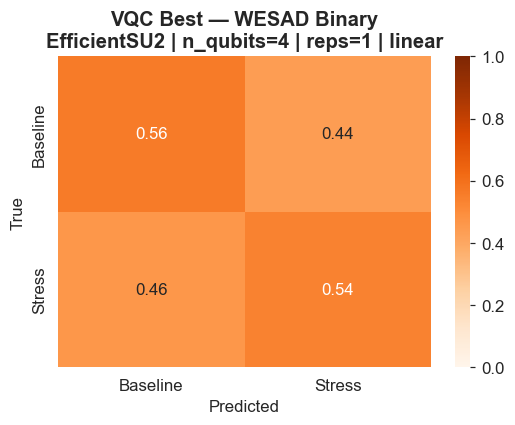

Saved: ..\results\plots\08_vqc\cm_vqc_wesad_binary_best.png


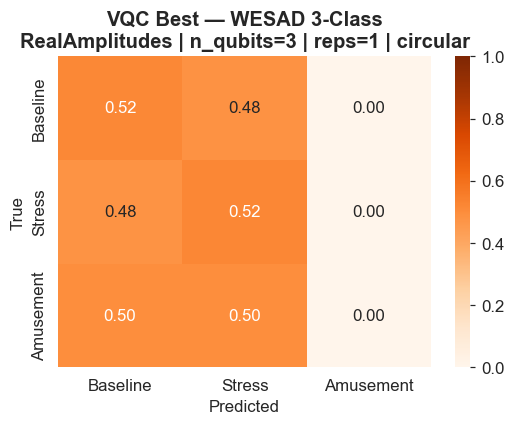

Saved: ..\results\plots\08_vqc\cm_vqc_wesad_3class_best.png


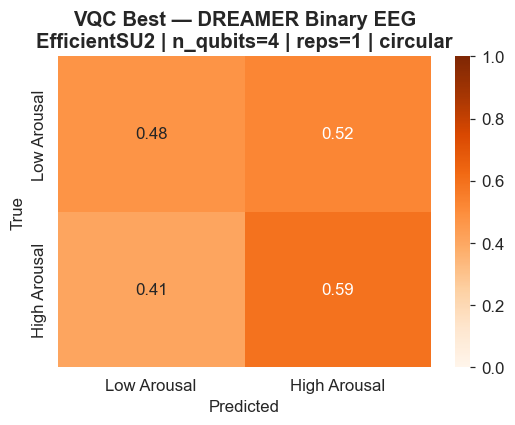

Saved: ..\results\plots\08_vqc\cm_vqc_dreamer_binary_best.png


In [21]:
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(best_cm_wb, ['Baseline','Stress'],
        f'VQC Best — WESAD Binary\n{best_cfg_wb}',
        os.path.join(PLOTS_DIR, 'cm_vqc_wesad_binary_best.png'))
plot_cm(best_cm_w3, ['Baseline','Stress','Amusement'],
        f'VQC Best — WESAD 3-Class\n{best_cfg_w3}',
        os.path.join(PLOTS_DIR, 'cm_vqc_wesad_3class_best.png'))
plot_cm(best_cm_db, ['Low Arousal','High Arousal'],
        f'VQC Best — DREAMER Binary EEG\n{best_cfg_db}',
        os.path.join(PLOTS_DIR, 'cm_vqc_dreamer_binary_best.png'))


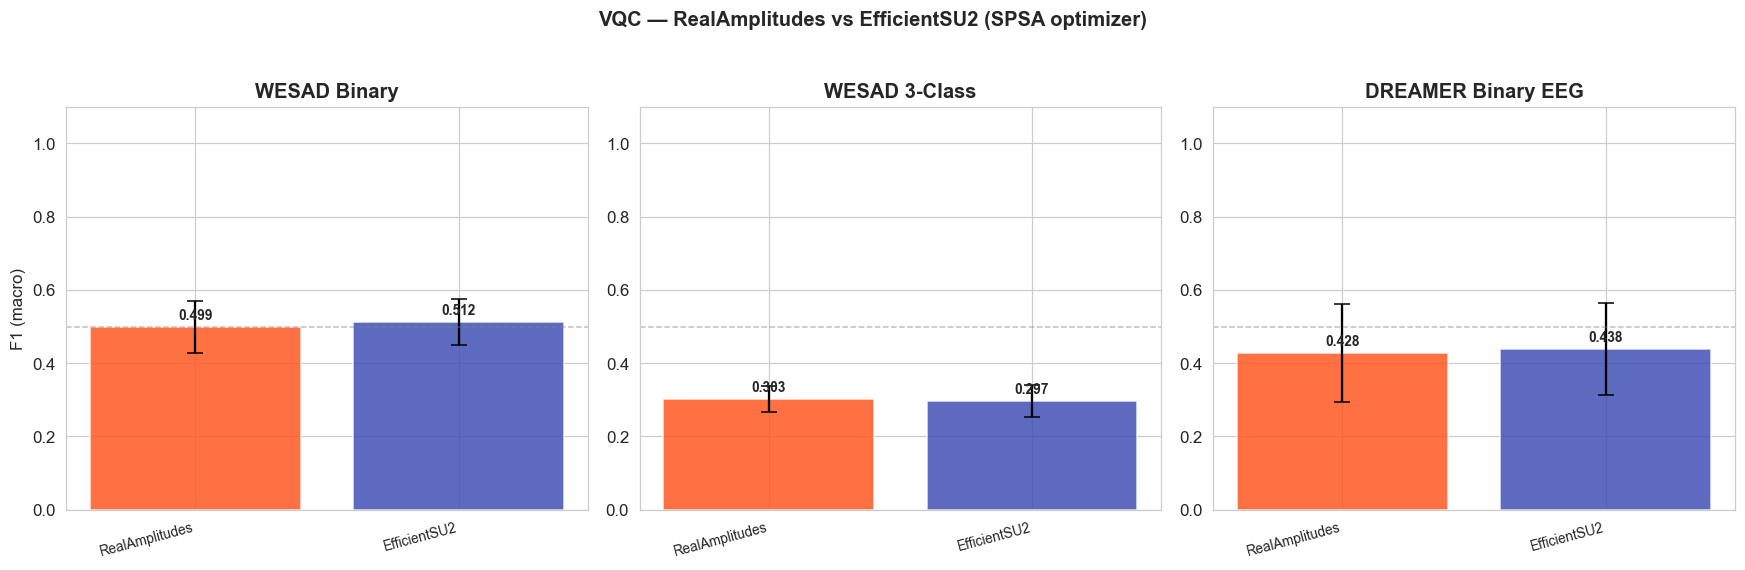

Saved: ..\results\plots\08_vqc\vqc_ansatz_comparison.png


In [22]:
# Ansatz comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ansatz_colors = {'RealAmplitudes': '#FF5722', 'EfficientSU2': '#3F51B5'}
tasks_plot = [
    ('WESAD_binary_VQC',      'WESAD Binary'),
    ('WESAD_3class_VQC',      'WESAD 3-Class'),
    ('DREAMER_binary_EEG_VQC','DREAMER Binary EEG'),
]
for ax, (task_key, task_label) in zip(axes, tasks_plot):
    td = all_results[all_results['task']==task_key]
    for j, ansatz in enumerate(ANSATZ_NAMES):
        vals = td[td['ansatz']==ansatz]['f1']
        if len(vals)==0: continue
        ax.bar(j, vals.mean(), color=ansatz_colors[ansatz],
               alpha=0.85, yerr=vals.std(), capsize=5)
        ax.text(j, vals.mean()+0.02, f'{vals.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax==axes[0] else '')
    ax.set_xticks(range(len(ANSATZ_NAMES)))
    ax.set_xticklabels(ANSATZ_NAMES, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
plt.suptitle('VQC — RealAmplitudes vs EfficientSU2 (SPSA optimizer)',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'vqc_ansatz_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


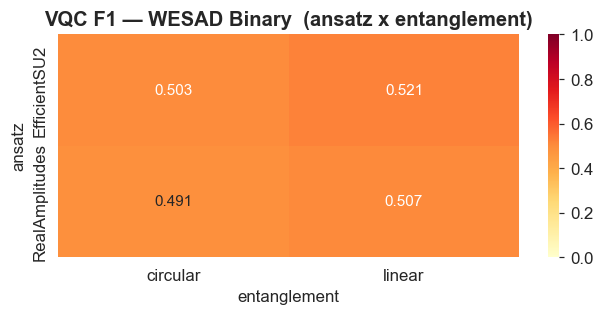

Saved: ..\results\plots\08_vqc\vqc_heatmap_wesad_binary_vqc.png


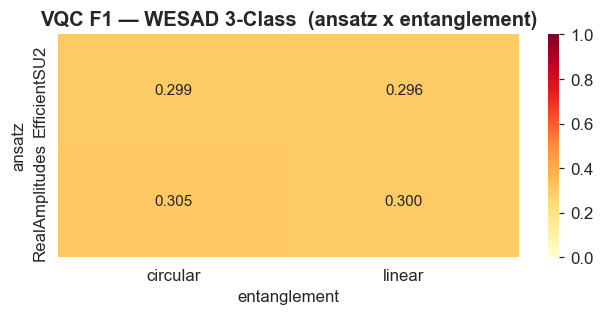

Saved: ..\results\plots\08_vqc\vqc_heatmap_wesad_3class_vqc.png


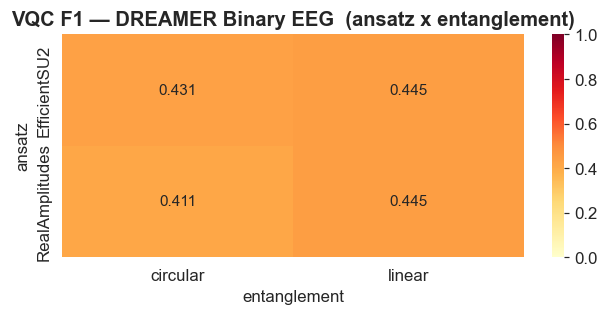

Saved: ..\results\plots\08_vqc\vqc_heatmap_dreamer_binary_eeg_vqc.png


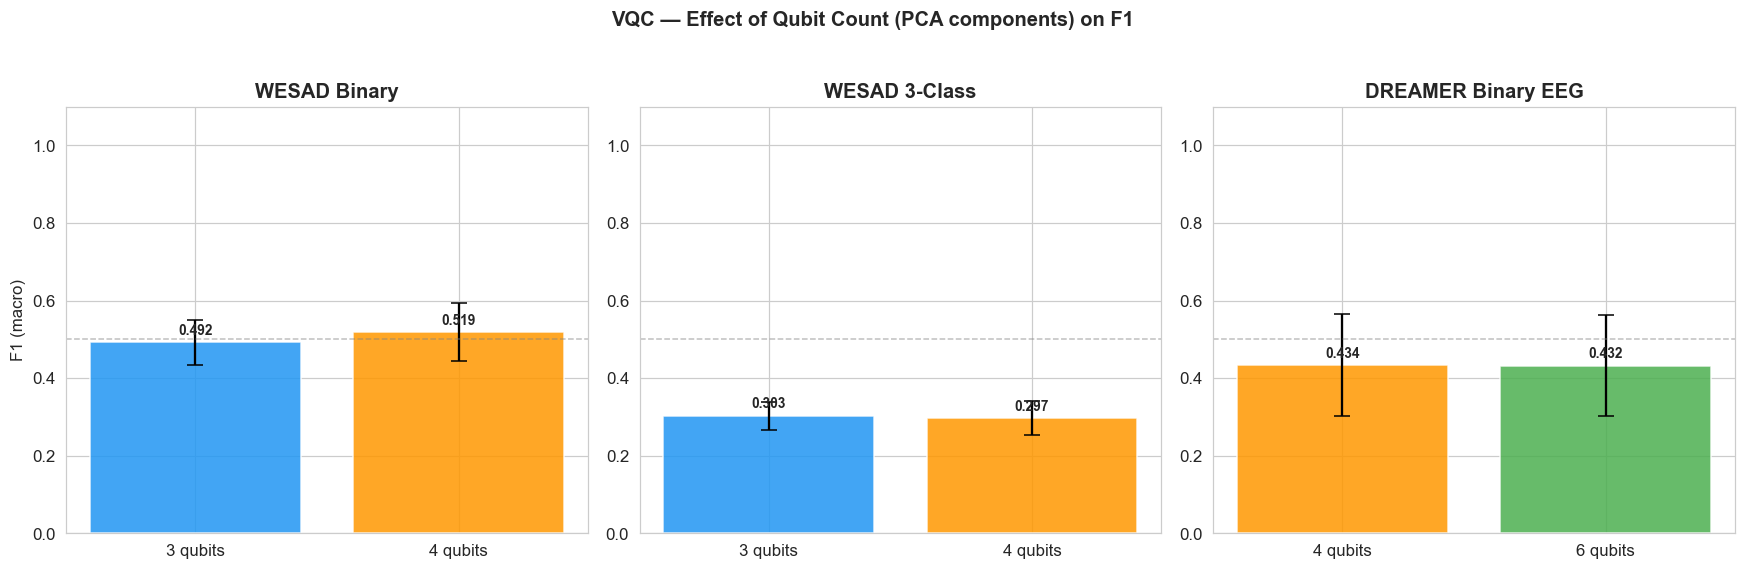

Saved: ..\results\plots\08_vqc\vqc_n_qubits_comparison.png


In [23]:
# F1 heatmap: ansatz x entanglement per task
for task_key, task_label in tasks_plot:
    td = all_results[all_results['task']==task_key]
    if len(td) == 0: continue
    pivot = td.groupby(['ansatz','entanglement'])['f1'].mean().unstack()
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, vmin=0, vmax=1, annot_kws={'size':10})
    ax.set_title(f'VQC F1 — {task_label}  (ansatz x entanglement)',
                 fontweight='bold')
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, f'vqc_heatmap_{task_key.lower()}.png')
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')

# n_qubits effect per task
qubit_colors = {3:'#2196F3', 4:'#FF9800', 6:'#4CAF50'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (task_key, task_label, pca_list) in zip(axes, [
        ('WESAD_binary_VQC',      'WESAD Binary',       PCA_COMPONENTS_WESAD),
        ('WESAD_3class_VQC',      'WESAD 3-Class',      PCA_COMPONENTS_WESAD),
        ('DREAMER_binary_EEG_VQC','DREAMER Binary EEG', PCA_COMPONENTS_DREAMER)]):
    td = all_results[all_results['task']==task_key]
    for xi, nq in enumerate(pca_list):
        vals = td[td['n_qubits']==nq]['f1']
        if len(vals)==0: continue
        ax.bar(xi, vals.mean(), color=qubit_colors.get(nq,'gray'),
               alpha=0.85, yerr=vals.std(), capsize=5)
        ax.text(xi, vals.mean()+0.02, f'{vals.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax==axes[0] else '')
    ax.set_xticks(range(len(pca_list)))
    ax.set_xticklabels([f'{nq} qubits' for nq in pca_list])
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
plt.suptitle('VQC — Effect of Qubit Count (PCA components) on F1',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'vqc_n_qubits_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 10. Stress/Amusement Overlap Analysis

In [24]:
print('=== VQC Best Config: Stress/Amusement Confusion ===')
cm = best_cm_w3
total_stress = cm[1,:].sum()
total_amuse  = cm[2,:].sum()
s_a = cm[1,2] / total_stress if total_stress > 0 else 0
a_s = cm[2,1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

vqc_overlap = pd.DataFrame([{
    'model'                  : f'VQC ({best_cfg_w3})',
    'stress->amusement_rate' : round(s_a, 4),
    'amusement->stress_rate' : round(a_s, 4),
}])
overlap_path = os.path.join(OUTPUT_DATA_DIR, 'overlap_classical_vs_qsvm.csv')
if os.path.exists(overlap_path):
    combined = pd.concat([pd.read_csv(overlap_path), vqc_overlap],
                          ignore_index=True)
else:
    combined = vqc_overlap
p = os.path.join(OUTPUT_DATA_DIR, 'overlap_all_models.csv')
combined.to_csv(p, index=False)
print('\n=== Full Overlap Comparison (all models) ===')
print(combined.to_string(index=False))
print(f'\nSaved: {p}')


=== VQC Best Config: Stress/Amusement Confusion ===
  Stress -> Amusement : 0/313 (0.0%)
  Amusement -> Stress : 83/166  (50.0%)

=== Full Overlap Comparison (all models) ===
                                                    model  stress->amusement_rate  amusement->stress_rate
                                      Logistic Regression                  0.1150                  0.0482
                                                SVM (RBF)                  0.1246                  0.0602
                                            Random Forest                  0.0511                  0.1145
QSVM (ZZFeatureMap | n_qubits=3 | reps=2 | full | robust)                  0.2684                  0.2229
    VQC (RealAmplitudes | n_qubits=3 | reps=1 | circular)                  0.0000                  0.5000

Saved: ..\results\output_data\overlap_all_models.csv


## 11. Summary Log

In [ ]:
best_results = {}
for task in all_results['task'].unique():
    td       = all_results[all_results['task']==task]
    best_row = td.groupby('config')['f1'].mean().idxmax()
    bd       = td[td['config']==best_row]
    best_results[task] = {
        'best_config'    : best_row,
        'f1_mean'        : round(bd['f1'].mean(), 4),
        'f1_std'         : round(bd['f1'].std(),  4),
        'accuracy_mean'  : round(bd['accuracy'].mean(), 4),
        'train_time_mean': round(bd['train_time'].mean(), 2),
    }

summary = {
    'notebook'    : '08_vqc_experiments_SPSA',
    'timestamp'   : datetime.now().isoformat(),
    'experiment_grid': {
        'ansatz'               : ANSATZ_NAMES,
        'pca_components_wesad' : PCA_COMPONENTS_WESAD,
        'pca_components_dreamer': PCA_COMPONENTS_DREAMER,
        'reps'                 : REPS_LIST,
        'entanglements'        : ENTANGLEMENTS,
        'optimizer'            : f'SPSA(maxiter={MAX_ITER})',
        'n_samples_per_class'  : N_SAMPLES_PER_CLASS,
        'pre_pca_scaler'       : 'RobustScaler',
        'post_pca_scaler'      : 'MinMaxScaler(-pi, pi)',
    },
    'best_results': best_results,
    'next'        : '09_results_analysis.ipynb'
}

p = os.path.join(LOGS_DIR, '08_vqc_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('VQC EXPERIMENTS COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


VQC EXPERIMENTS COMPLETE
{
  "notebook": "08_vqc_experiments",
  "timestamp": "2026-05-11T04:38:01.455387",
  "experiment_grid": {
    "ansatz": [
      "RealAmplitudes",
      "EfficientSU2"
    ],
    "pca_components_wesad": [
      3,
      4
    ],
    "pca_components_dreamer": [
      4,
      6
    ],
    "reps": [
      1
    ],
    "entanglements": [
      "linear",
      "circular"
    ],
    "optimizer": "SPSA(maxiter=30)",
    "n_samples_per_class": 30,
    "pre_pca_scaler": "RobustScaler",
    "post_pca_scaler": "MinMaxScaler(-pi, pi)"
  },
  "best_results": {
    "WESAD_binary_VQC": {
      "best_config": "EfficientSU2_n4_r1_linear",
      "f1_mean": 0.5357,
      "f1_std": 0.0752,
      "accuracy_mean": 0.5516,
      "train_time_mean": 93.99
    },
    "WESAD_3class_VQC": {
      "best_config": "RealAmplitudes_n3_r1_circular",
      "f1_mean": 0.3079,
      "f1_std": 0.0371,
      "accuracy_mean": 0.4353,
      "train_time_mean": 25.3
    },
    "DREAMER_binary_EEG_VQC": 